# A local timestamp is not a point in time

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/timezone-normalizer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/timezone-normalizer/demo.ipynb)

**Day 139 - Data Engineering Pro.**

`2024-11-03 01:30` in New York happened twice, an hour apart. `2024-03-10 02:30`
in New York never happened at all. `zoneinfo` returns a UTC value for both without
raising - PEP 495 made both readings representable via the `fold` attribute, which
is correct and complete, and which also means the guess is made for you silently.

Six mechanisms, each measured against instants that actually happened:

| | mechanism | effect on the sample |
|---|---|---|
| A | the wall clock reads 01:00-01:59 twice | a session lasts **-40 minutes** |
| B | the clock skips 02:00-02:59 (or 02:00-02:29) | accepted silently, round trip fails |
| C | an offset in the payload | recovers both contested sessions exactly |
| D | `Asia/Calcutta` == `Asia/Kolkata`; `Etc/GMT+5` is UTC**-**5 | one office split in two |
| E | UTC day vs local day | 6 of 24 events change day, totals still reconcile |
| F | +05:45, +13:45, and a 30-minute DST shift | 3 of 7 zones miss the hour grid |

None of the eight entries in the damage ledger raise. Six are *stable*, so
re-running the pipeline reproduces the same wrong number.

**The sample is generated from true UTC instants** and the local wall-clock strings
are rendered from them with the offset dropped - which is exactly what a system does
when it writes local `now()` into a `TIMESTAMP` column. That makes the ground truth
intrinsic, so everything below is a real recovery error rather than two guesses
compared to each other.


## Setup

Both modules are embedded and written to disk, so this runs standalone on Colab or
Binder. `tznorm.py` is standard library only - `zoneinfo`, no pytz, no pandas.

In [1]:
_src = "\"\"\"Normalising local timestamps to UTC, with the ambiguous cases named.\n\nA local wall-clock timestamp is not a point in time. Twice a year it is either\ntwo points in time or none, and for the rest of the year it is one point only if\nyou also know the zone - not the offset, the *zone*, because an offset cannot\ntell you what the clock will do next month.\n\n`datetime` with `zoneinfo` never raises on either case. PEP 495 gave every aware\ndatetime a `fold` attribute and made both readings representable, which is\ncorrect and complete, and also means the failure is silent by construction: you\nget an answer for 01:30 on the fall-back night whether or not you meant the\nfirst one.\n\nThis module resolves each timestamp explicitly, records *which* case it hit, and\nrefuses to guess unless told which way to guess.\n\nStandard library only - `zoneinfo`, no pytz, no pandas.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport datetime as dt\nfrom dataclasses import dataclass, field as _dcfield\nfrom typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple\nfrom zoneinfo import ZoneInfo, ZoneInfoNotFoundError\n\n__all__ = [\n    \"AmbiguousTime\",\n    \"NonExistentTime\",\n    \"UnknownZone\",\n    \"Reading\",\n    \"classify\",\n    \"resolve\",\n    \"normalize\",\n    \"tzdata_version\",\n    \"same_rules\",\n    \"find_alias_groups\",\n    \"etc_zone_is_inverted\",\n    \"local_day\",\n    \"utc_day\",\n    \"audit\",\n    \"AuditReport\",\n    \"build_session_log\",\n    \"ground_truth\",\n    \"SESSION_COLUMNS\",\n]\n\nUTC = dt.timezone.utc\n\n\n# --------------------------------------------------------------------------\n# errors\n# --------------------------------------------------------------------------\n\n\nclass AmbiguousTime(ValueError):\n    \"\"\"The wall clock read this twice. Which one did you mean?\"\"\"\n\n\nclass NonExistentTime(ValueError):\n    \"\"\"The wall clock never read this. It was skipped by a forward transition.\"\"\"\n\n\nclass UnknownZone(ValueError):\n    \"\"\"The zone identifier is not in this machine's tz database.\"\"\"\n\n\n# --------------------------------------------------------------------------\n# the two hard cases\n# --------------------------------------------------------------------------\n\n\ndef classify(naive: dt.datetime, zone: str) -> str:\n    \"\"\"``ok``, ``ambiguous`` or ``nonexistent`` for a wall-clock time in a zone.\n\n    The test is a round trip, which is the only definition that does not depend\n    on knowing the transition table. Convert the wall time to UTC and back: an\n    ordinary time returns itself, a skipped time cannot and comes back as some\n    other wall time, and an ambiguous time returns itself under both folds while\n    the two folds carry different offsets.\n    \"\"\"\n    tz = _zone(zone)\n    aware0 = naive.replace(tzinfo=tz, fold=0)\n    aware1 = naive.replace(tzinfo=tz, fold=1)\n    round_trip = aware0.astimezone(UTC).astimezone(tz).replace(tzinfo=None, fold=0)\n    if round_trip != naive.replace(fold=0):\n        return \"nonexistent\"\n    if aware0.utcoffset() != aware1.utcoffset():\n        return \"ambiguous\"\n    return \"ok\"\n\n\ndef _zone(zone: str) -> ZoneInfo:\n    try:\n        return ZoneInfo(zone)\n    except (ZoneInfoNotFoundError, ValueError) as exc:\n        raise UnknownZone(f\"{zone!r} is not in this machine's tz database ({exc})\") from None\n\n\n# --------------------------------------------------------------------------\n# a single reading\n# --------------------------------------------------------------------------\n\n\n@dataclass(frozen=True)\nclass Reading:\n    \"\"\"One timestamp, resolved or explicitly not.\"\"\"\n\n    raw: str\n    zone: str\n    status: str\n    utc: Optional[dt.datetime] = None\n    local: Optional[dt.datetime] = None\n    offset: Optional[dt.timedelta] = None\n    note: str = \"\"\n\n    @property\n    def ok(self) -> bool:\n        return self.utc is not None\n\n    def offset_hours(self) -> Optional[float]:\n        return None if self.offset is None else self.offset.total_seconds() / 3600\n\n\ndef _parse(raw: str) -> Optional[dt.datetime]:\n    \"\"\"Parse a wall-clock string. Anything carrying its own offset is returned aware.\"\"\"\n    text = raw.strip().replace(\" \", \"T\", 1) if \" \" in raw.strip() else raw.strip()\n    try:\n        return dt.datetime.fromisoformat(text)\n    except ValueError:\n        for fmt in (\"%Y-%m-%dT%H:%M:%S\", \"%Y-%m-%dT%H:%M\", \"%d/%m/%Y %H:%M\", \"%m/%d/%Y %H:%M\"):\n            try:\n                return dt.datetime.strptime(raw.strip(), fmt)\n            except ValueError:\n                continue\n    return None\n\n\ndef resolve(\n    raw: str,\n    zone: str,\n    ambiguous: str = \"raise\",\n    nonexistent: str = \"raise\",\n) -> Reading:\n    \"\"\"Resolve one local timestamp to UTC.\n\n    ``ambiguous``   - ``raise`` | ``earlier`` (fold=0) | ``later`` (fold=1) | ``flag``\n    ``nonexistent`` - ``raise`` | ``shift_forward`` | ``flag``\n\n    The defaults raise, because in both cases the input does not determine the\n    answer and a default that quietly picks one is how a duration ends up\n    negative in a table nobody re-reads.\n    \"\"\"\n    parsed = _parse(raw)\n    if parsed is None:\n        return Reading(raw, zone, \"unparsed\", note=\"no recognised date format\")\n\n    if parsed.tzinfo is not None:\n        # Already carries an offset. That pins the instant but not the zone - see\n        # `Reading.note`, and experiment D.\n        return Reading(\n            raw,\n            zone,\n            \"offset_only\",\n            utc=parsed.astimezone(UTC),\n            local=parsed.replace(tzinfo=None),\n            offset=parsed.utcoffset(),\n            note=(\n                \"the string carried a fixed offset, so the instant is pinned but the \"\n                \"zone is not - this value cannot answer 'same local time next month'\"\n            ),\n        )\n\n    tz = _zone(zone)\n    kind = classify(parsed, zone)\n\n    if kind == \"ambiguous\":\n        if ambiguous == \"raise\":\n            raise AmbiguousTime(\n                f\"{raw} occurs twice in {zone}: \"\n                f\"{parsed.replace(tzinfo=tz, fold=0).astimezone(UTC)} and \"\n                f\"{parsed.replace(tzinfo=tz, fold=1).astimezone(UTC)}\"\n            )\n        if ambiguous == \"flag\":\n            return Reading(raw, zone, \"ambiguous\", note=\"occurs twice; unresolved by request\")\n        fold = 0 if ambiguous == \"earlier\" else 1\n        aware = parsed.replace(tzinfo=tz, fold=fold)\n        return Reading(\n            raw,\n            zone,\n            \"ambiguous\",\n            utc=aware.astimezone(UTC),\n            local=parsed,\n            offset=aware.utcoffset(),\n            note=f\"occurs twice; took the {'earlier' if fold == 0 else 'later'} reading\",\n        )\n\n    if kind == \"nonexistent\":\n        if nonexistent == \"raise\":\n            raise NonExistentTime(f\"{raw} does not exist in {zone}: skipped by a forward transition\")\n        if nonexistent == \"flag\":\n            return Reading(raw, zone, \"nonexistent\", note=\"clock skipped this time; unresolved\")\n        # shift_forward: land on the first instant that does exist\n        aware = parsed.replace(tzinfo=tz, fold=1)\n        shifted = aware.astimezone(UTC)\n        return Reading(\n            raw,\n            zone,\n            \"nonexistent\",\n            utc=shifted,\n            local=shifted.astimezone(tz).replace(tzinfo=None),\n            offset=shifted.astimezone(tz).utcoffset(),\n            note=\"clock skipped this time; shifted forward past the gap\",\n        )\n\n    aware = parsed.replace(tzinfo=tz)\n    return Reading(raw, zone, \"ok\", utc=aware.astimezone(UTC), local=parsed, offset=aware.utcoffset())\n\n\ndef normalize(\n    rows: Sequence[Dict[str, Any]],\n    ts_key: str = \"local_ts\",\n    zone_key: str = \"zone\",\n    ambiguous: str = \"flag\",\n    nonexistent: str = \"flag\",\n) -> List[Reading]:\n    \"\"\"Resolve a column of local timestamps. Defaults to flagging, not guessing.\"\"\"\n    out: List[Reading] = []\n    for row in rows:\n        try:\n            out.append(resolve(row[ts_key], row[zone_key], ambiguous, nonexistent))\n        except UnknownZone as exc:\n            out.append(Reading(row[ts_key], row[zone_key], \"unknown_zone\", note=str(exc)))\n    return out\n\n\n# --------------------------------------------------------------------------\n# the tz database itself\n# --------------------------------------------------------------------------\n\n\ndef tzdata_version() -> str:\n    \"\"\"Which rules produced these answers.\n\n    Time zone rules are political and change several times a year. Two runs of\n    the same code against the same input give different UTC values if the tz\n    database moved underneath them, so the version belongs in the output next to\n    the numbers, not in a comment.\n    \"\"\"\n    try:\n        import tzdata  # noqa: PLC0415 - optional, present only when pip-installed\n\n        return f\"tzdata {tzdata.__version__} (Python package)\"\n    except Exception:  # noqa: BLE001 - any failure means we are on the system db\n        pass\n    for path in (\"/usr/share/zoneinfo/+VERSION\", \"/usr/lib/zoneinfo/+VERSION\"):\n        try:\n            with open(path) as fh:\n                return f\"tzdata {fh.read().strip()} (system)\"\n        except OSError:\n            continue\n    return \"tzdata version unknown\"\n\n\ndef same_rules(a: str, b: str, start_year: int = 1990, end_year: int = 2035) -> bool:\n    \"\"\"Do two zone identifiers behave identically over a long window?\n\n    zoneinfo does not expose the tz database's Link records, so identity is\n    established behaviourally: sample the offset every six hours across decades\n    and compare. Slower than reading a link table and correct without one.\n    \"\"\"\n    za, zb = _zone(a), _zone(b)\n    cursor = dt.datetime(start_year, 1, 1)\n    step = dt.timedelta(hours=6)\n    end = dt.datetime(end_year, 1, 1)\n    while cursor < end:\n        if cursor.replace(tzinfo=za).utcoffset() != cursor.replace(tzinfo=zb).utcoffset():\n            return False\n        cursor += step\n    return True\n\n\ndef find_alias_groups(zones: Iterable[str]) -> List[List[str]]:\n    \"\"\"Group the zone identifiers present in the data by actual behaviour.\n\n    Any group with more than one member is a set of names for the same place -\n    a `GROUP BY zone` splits that place's rows across several buckets while every\n    per-row conversion stays perfectly correct.\n    \"\"\"\n    unique = sorted(set(zones))\n    groups: List[List[str]] = []\n    for z in unique:\n        try:\n            _zone(z)\n        except UnknownZone:\n            continue\n        for g in groups:\n            if same_rules(g[0], z):\n                g.append(z)\n                break\n        else:\n            groups.append([z])\n    return [g for g in groups if len(g) > 1]\n\n\ndef etc_zone_is_inverted(zone: str) -> Optional[str]:\n    \"\"\"`Etc/GMT+5` is UTC-05:00. The POSIX sign convention is the other way round.\n\n    Returns a description when the identifier's sign does not mean what a reader\n    of the name would assume, and None otherwise.\n    \"\"\"\n    if not zone.startswith(\"Etc/GMT\") or zone in (\"Etc/GMT\", \"Etc/GMT0\"):\n        return None\n    try:\n        off = dt.datetime(2024, 7, 1, tzinfo=_zone(zone)).utcoffset()\n    except UnknownZone:\n        return None\n    if off is None:\n        return None\n    hours = off.total_seconds() / 3600\n    sign_in_name = \"+\" if \"+\" in zone else \"-\"\n    actual = \"+\" if hours >= 0 else \"-\"\n    if sign_in_name != actual:\n        return f\"{zone} is UTC{hours:+03.0f}:00 - the POSIX sign convention is inverted\"\n    return None\n\n\n# --------------------------------------------------------------------------\n# day bucketing\n# --------------------------------------------------------------------------\n\n\ndef utc_day(reading: Reading) -> Optional[dt.date]:\n    return None if reading.utc is None else reading.utc.date()\n\n\ndef local_day(reading: Reading) -> Optional[dt.date]:\n    \"\"\"The calendar day the event happened on *where it happened*.\n\n    Not the same question as `utc_day`, and for anywhere east of London or west\n    of Reykjavik it is frequently a different answer.\n    \"\"\"\n    if reading.utc is None:\n        return None\n    try:\n        return reading.utc.astimezone(_zone(reading.zone)).date()\n    except UnknownZone:\n        return None\n\n\n# --------------------------------------------------------------------------\n# audit\n# --------------------------------------------------------------------------\n\n\n@dataclass\nclass AuditReport:\n    verdict: str\n    findings: List[str]\n    stats: Dict[str, Any] = _dcfield(default_factory=dict)\n\n    def text(self) -> str:\n        return \"\\n\".join([self.verdict] + [f\"  {f}\" for f in self.findings])\n\n    def __str__(self) -> str:  # pragma: no cover - convenience\n        return self.text()\n\n\ndef audit(\n    rows: Sequence[Dict[str, Any]], ts_key: str = \"local_ts\", zone_key: str = \"zone\"\n) -> AuditReport:\n    \"\"\"Everything about this column that a UTC conversion will not tell you.\n\n    Runs before the conversion, and reports only failures that produce a\n    plausible answer - a timestamp that cannot be parsed is not interesting here,\n    because it announces itself.\n    \"\"\"\n    findings: List[str] = []\n    stats: Dict[str, Any] = {\"tzdata\": tzdata_version(), \"rows\": len(rows)}\n    readings = normalize(rows, ts_key, zone_key, ambiguous=\"flag\", nonexistent=\"flag\")\n\n    counts: Dict[str, int] = {}\n    for r in readings:\n        counts[r.status] = counts.get(r.status, 0) + 1\n    stats[\"status_counts\"] = counts\n\n    if counts.get(\"ambiguous\"):\n        n = counts[\"ambiguous\"]\n        findings.append(\n            f\"WARNING {n} timestamp(s) occur twice in their zone - a clock going back. \"\n            f\"Both readings are real instants an hour apart, the input does not say which, \"\n            f\"and Python will not raise: `datetime` carries a `fold` flag that defaults to 0, \"\n            f\"so the earlier reading is chosen for you\"\n        )\n    if counts.get(\"nonexistent\"):\n        n = counts[\"nonexistent\"]\n        findings.append(\n            f\"WARNING {n} timestamp(s) never happened - a clock going forward skipped them. \"\n            f\"zoneinfo still returns a UTC value, and converting it back gives a *different* \"\n            f\"wall time from the one you started with\"\n        )\n    if counts.get(\"offset_only\"):\n        n = counts[\"offset_only\"]\n        findings.append(\n            f\"note  {n} value(s) already carried a numeric offset. The instant is pinned, \"\n            f\"the zone is not - an offset cannot answer 'what will this clock read in \"\n            f\"December', because that depends on rules the offset does not carry\"\n        )\n    if counts.get(\"unknown_zone\"):\n        findings.append(\n            f\"ERROR {counts['unknown_zone']} row(s) name a zone this machine's tz database \"\n            f\"does not have\"\n        )\n    if counts.get(\"unparsed\"):\n        findings.append(f\"note  {counts['unparsed']} value(s) could not be parsed at all\")\n\n    zones = [str(r[zone_key]) for r in rows]\n    groups = find_alias_groups(zones)\n    stats[\"alias_groups\"] = groups\n    for g in groups:\n        affected = sum(1 for z in zones if z in g)\n        findings.append(\n            f\"WARNING {' and '.join(g)} are the same zone under different names \"\n            f\"({affected} rows). Every conversion is correct; a GROUP BY on the zone column \"\n            f\"splits one place into {len(g)} buckets\"\n        )\n\n    for z in sorted(set(zones)):\n        msg = etc_zone_is_inverted(z)\n        if msg:\n            findings.append(f\"WARNING {msg}\")\n\n    offsets = {r.offset for r in readings if r.offset is not None}\n    odd = sorted(\n        {o for o in offsets if o.total_seconds() % 3600}, key=lambda o: o.total_seconds()\n    )\n    stats[\"sub_hour_offsets\"] = [str(o) for o in odd]\n    if odd:\n        findings.append(\n            f\"note  {len(odd)} distinct offset(s) in this data are not a whole number of hours \"\n            f\"({', '.join(str(o) for o in odd)}). Any bucketing that assumes hour boundaries \"\n            f\"align across zones is wrong for these rows\"\n        )\n\n    findings.append(f\"note  resolved against {stats['tzdata']} - record this next to the results\")\n\n    n_bad = counts.get(\"ambiguous\", 0) + counts.get(\"nonexistent\", 0)\n    if counts.get(\"unknown_zone\"):\n        verdict = \"NOT SAFE TO CONVERT - unknown zone identifiers\"\n    elif n_bad:\n        verdict = (\n            f\"CONVERTS, BUT {n_bad} OF {len(rows)} ROWS ARE UNDETERMINED - the input does not \"\n            f\"say which instant it means\"\n        )\n    elif any(f.startswith(\"WARNING\") for f in findings):\n        verdict = f\"CONVERTS - every row resolves, but {sum(1 for f in findings if f.startswith('WARNING'))} structural warning(s)\"\n    else:\n        verdict = f\"CLEAN - {len(rows)} rows resolve to exactly one instant each\"\n\n    return AuditReport(verdict, findings, stats)\n\n\n# --------------------------------------------------------------------------\n# sample data\n# --------------------------------------------------------------------------\n\nSESSION_COLUMNS = (\"session_id\", \"office\", \"zone\", \"local_ts\", \"event\", \"amount\")\n\n#: (session, office, zone, true UTC instant or None, event, amount)\n#:\n#: The sample is generated *from* true instants and the local wall-clock string is\n#: rendered from them, with the offset dropped - which is exactly what a system\n#: does when it writes `datetime.now()` in local time into a `TIMESTAMP` column.\n#: That makes the ground truth intrinsic rather than asserted, so every experiment\n#: below measures real recovery error instead of comparing two guesses.\n#:\n#: `true_utc=None` marks a row whose local timestamp was *derived* rather than\n#: observed - computed as \"start + 45 minutes\" in local terms by an upstream job.\n#: Those are the rows that land on wall-clock times which never existed.\n_TRUTH: List[Tuple[str, str, str, Optional[str], str, float]] = [\n    # New York, the night the clocks go back. 06:00Z is the transition.\n    (\"S-101\", \"New York\", \"America/New_York\", \"2024-11-03T04:45:00Z\", \"open\", 0.0),\n    (\"S-101\", \"New York\", \"America/New_York\", \"2024-11-03T04:58:00Z\", \"close\", 120.0),\n    # opens before the transition, closes after it: 80 real minutes\n    (\"S-104\", \"New York\", \"America/New_York\", \"2024-11-03T05:30:00Z\", \"open\", 0.0),\n    (\"S-104\", \"New York\", \"America/New_York\", \"2024-11-03T06:50:00Z\", \"close\", 340.0),\n    # same, and the wall clock runs backwards across it: 20 real minutes\n    (\"S-105\", \"New York\", \"America/New_York\", \"2024-11-03T05:50:00Z\", \"open\", 0.0),\n    (\"S-105\", \"New York\", \"America/New_York\", \"2024-11-03T06:10:00Z\", \"close\", 90.0),\n    # New York, the night the clocks go forward. 07:00Z is the transition.\n    (\"S-110\", \"New York\", \"America/New_York\", \"2024-03-10T06:45:00Z\", \"open\", 0.0),\n    (\"S-110\", \"New York\", \"America/New_York\", None, \"close\", 210.0),  # derived: 02:30 never existed\n    # London, clocks back\n    (\"S-201\", \"London\", \"Europe/London\", \"2024-10-27T00:30:00Z\", \"open\", 0.0),\n    (\"S-201\", \"London\", \"Europe/London\", \"2024-10-27T03:05:00Z\", \"close\", 480.0),\n    # Singapore: no DST, but far enough east to change the calendar day\n    (\"S-301\", \"Singapore\", \"Asia/Singapore\", \"2024-11-03T00:15:00Z\", \"open\", 0.0),\n    (\"S-301\", \"Singapore\", \"Asia/Singapore\", \"2024-11-03T01:05:00Z\", \"close\", 1250.0),\n    (\"S-302\", \"Singapore\", \"Asia/Singapore\", \"2024-11-03T23:40:00Z\", \"open\", 0.0),\n    (\"S-302\", \"Singapore\", \"Asia/Singapore\", \"2024-11-04T00:20:00Z\", \"close\", 640.0),\n    # Bengaluru, logged under two different names for the same zone\n    (\"S-401\", \"Bengaluru\", \"Asia/Calcutta\", \"2024-11-03T04:00:00Z\", \"open\", 0.0),\n    (\"S-401\", \"Bengaluru\", \"Asia/Calcutta\", \"2024-11-03T04:45:00Z\", \"close\", 410.0),\n    (\"S-402\", \"Bengaluru\", \"Asia/Kolkata\", \"2024-11-03T18:50:00Z\", \"open\", 0.0),\n    (\"S-402\", \"Bengaluru\", \"Asia/Kolkata\", \"2024-11-03T19:35:00Z\", \"close\", 380.0),\n    # Kathmandu: +05:45\n    (\"S-501\", \"Kathmandu\", \"Asia/Kathmandu\", \"2024-11-03T08:20:00Z\", \"open\", 0.0),\n    (\"S-501\", \"Kathmandu\", \"Asia/Kathmandu\", \"2024-11-03T18:40:00Z\", \"close\", 220.0),\n    # Lord Howe: a THIRTY minute DST shift, so the spring gap is half an hour wide\n    (\"S-601\", \"Lord Howe\", \"Australia/Lord_Howe\", None, \"open\", 0.0),  # derived: 02:15 never existed\n    (\"S-601\", \"Lord Howe\", \"Australia/Lord_Howe\", \"2024-10-05T16:40:00Z\", \"close\", 95.0),\n    # a vendor feed labelled with a POSIX-style identifier\n    (\"S-701\", \"Vendor feed\", \"Etc/GMT+5\", \"2024-11-03T17:00:00Z\", \"open\", 0.0),\n    (\"S-701\", \"Vendor feed\", \"Etc/GMT+5\", \"2024-11-03T17:45:00Z\", \"close\", 700.0),\n]\n\n#: The same fall-back sessions from a partner API that transmits the offset.\n#: Same instants, same wall-clock times, one extra field - and it is decidable.\n_PARTNER = [(\"S-104\", \"America/New_York\"), (\"S-105\", \"America/New_York\")]\n\n\ndef _render_local(utc_iso: str, zone: str, with_offset: bool = False) -> str:\n    \"\"\"Format a true instant as the local wall clock, dropping the offset.\n\n    This is the lossy step the whole module is about, and it is one line of\n    ordinary application code in every system that has ever done it.\n    \"\"\"\n    inst = dt.datetime.fromisoformat(utc_iso.replace(\"Z\", \"+00:00\")).astimezone(_zone(zone))\n    if with_offset:\n        return inst.isoformat(timespec=\"seconds\")\n    return inst.strftime(\"%Y-%m-%d %H:%M\")\n\n\n#: wall-clock strings for the two derived rows, which have no true instant\n_DERIVED = {(\"S-110\", \"close\"): \"2024-03-10 02:30\", (\"S-601\", \"open\"): \"2024-10-06 02:15\"}\n\n\ndef build_session_log(with_partner_feed: bool = False) -> List[Dict[str, Any]]:\n    \"\"\"Support sessions across six offices, straddling the 2024 transitions.\n\n    Set ``with_partner_feed`` to append the same two contested New York sessions\n    as they arrive from a feed that transmits the UTC offset alongside the wall\n    clock - the control group for experiment C.\n    \"\"\"\n    rows: List[Dict[str, Any]] = []\n    for sid, office, zone, utc_iso, event, amount in _TRUTH:\n        local = _DERIVED[(sid, event)] if utc_iso is None else _render_local(utc_iso, zone)\n        rows.append(\n            dict(zip(SESSION_COLUMNS, (sid, office, zone, local, event, amount)))\n        )\n    if with_partner_feed:\n        for sid, zone in _PARTNER:\n            for s, office, z, utc_iso, event, amount in _TRUTH:\n                if s == sid and utc_iso is not None:\n                    rows.append(\n                        dict(\n                            zip(\n                                SESSION_COLUMNS,\n                                (\n                                    f\"{sid}-api\",\n                                    \"Partner API\",\n                                    zone,\n                                    _render_local(utc_iso, zone, with_offset=True),\n                                    event,\n                                    amount,\n                                ),\n                            )\n                        )\n                    )\n    return rows\n\n\ndef ground_truth() -> Dict[Tuple[str, str], Optional[dt.datetime]]:\n    \"\"\"(session_id, event) -> the instant the event actually happened, or None.\"\"\"\n    return {\n        (sid, event): (\n            None\n            if utc_iso is None\n            else dt.datetime.fromisoformat(utc_iso.replace(\"Z\", \"+00:00\"))\n        )\n        for sid, _office, _zone, utc_iso, event, _amount in _TRUTH\n    }\n"
from pathlib import Path
Path("tznorm.py").write_text(_src)
print("wrote tznorm.py:", len(_src.splitlines()), "lines")


wrote tznorm.py: 582 lines


In [2]:
_src = "\"\"\"The experiments the README quotes. Every number below is produced here.\n\nRun ``python3 evidence.py`` to regenerate all of it. Nothing is random. The one\nthing that is not machine-independent is the tz database version, which is\nprinted with the results for exactly that reason.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport datetime as dt\nfrom typing import Any, Dict, List, Optional, Tuple\nfrom zoneinfo import ZoneInfo\n\nfrom tznorm import (\n    UTC,\n    Reading,\n    build_session_log,\n    classify,\n    etc_zone_is_inverted,\n    find_alias_groups,\n    ground_truth,\n    local_day,\n    normalize,\n    resolve,\n    same_rules,\n    tzdata_version,\n    utc_day,\n)\n\nRULE = \"-\" * 78\n\n\ndef _hdr(title: str) -> None:\n    print()\n    print(\"=\" * 78)\n    print(title)\n    print(\"=\" * 78)\n\n\ndef _sessions(rows: List[Dict[str, Any]], readings: List[Reading]) -> Dict[str, Dict[str, Reading]]:\n    out: Dict[str, Dict[str, Reading]] = {}\n    for row, r in zip(rows, readings):\n        out.setdefault(row[\"session_id\"], {})[row[\"event\"]] = r\n    return out\n\n\ndef _minutes(a: Optional[dt.datetime], b: Optional[dt.datetime]) -> Optional[float]:\n    if a is None or b is None:\n        return None\n    return (b - a).total_seconds() / 60\n\n\n# --------------------------------------------------------------------------\n# A. the hour that happens twice\n# --------------------------------------------------------------------------\n\n\ndef exp_ambiguous(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"Fall-back night, measured against the instants the events actually happened.\n\n    The sample's local strings are rendered *from* true UTC instants, so this is a\n    recovery error, not a comparison of two guesses.\n    \"\"\"\n    rows = build_session_log()\n    truth = ground_truth()\n    results: Dict[str, Dict[str, Any]] = {}\n\n    for policy in (\"earlier\", \"later\"):\n        readings = normalize(rows, ambiguous=policy, nonexistent=\"flag\")\n        by_session = _sessions(rows, readings)\n        for sid, ev in by_session.items():\n            if \"open\" not in ev or \"close\" not in ev:\n                continue\n            results.setdefault(sid, {})[policy] = _minutes(ev[\"open\"].utc, ev[\"close\"].utc)\n\n    for sid in list(results):\n        results[sid][\"truth\"] = _minutes(truth.get((sid, \"open\")), truth.get((sid, \"close\")))\n\n    contested = [\"S-101\", \"S-104\", \"S-105\"]\n    negatives = [s for s in results if (results[s].get(\"earlier\") or 0) < 0]\n\n    if verbose:\n        _hdr(\"A. The hour that happens twice\")\n        print(\n            \"New York, 2024-11-03. At 02:00 EDT the clock goes back to 01:00 EST, so the\\n\"\n            \"wall clock reads 01:00-01:59 twice, an hour apart. Three sessions in that\\n\"\n            \"window, with the durations the business thinks it is measuring:\\n\"\n        )\n        print(f\"{'session':<10}{'open (local)':>16}{'close (local)':>16}{'truth':>10}{'fold=0':>10}{'fold=1':>10}\")\n        print(RULE)\n        for sid in contested:\n            ev = {r[\"event\"]: r[\"local_ts\"] for r in rows if r[\"session_id\"] == sid}\n            t = results[sid]\n            f0 = t.get(\"earlier\")\n            f1 = t.get(\"later\")\n            print(\n                f\"{sid:<10}{ev['open'][11:]:>16}{ev['close'][11:]:>16}\"\n                f\"{t['truth']:>10.0f}{f0:>10.0f}{f1:>10.0f}\"\n            )\n        print(RULE)\n        print(\"  minutes. fold=0 is Python's default for an ambiguous wall time.\\n\")\n        print(\n            \"S-101 sits entirely before the transition, so every reading agrees - that is\\n\"\n            \"the control. S-104 really lasted 80 minutes and both fold policies report 20.\\n\"\n            \"S-105 really lasted 20 minutes and both report **-40**: a session that closed\\n\"\n            \"before it opened.\\n\"\n        )\n        print(\n            \"The important part is not that fold=0 is wrong. It is that **no single fold is\\n\"\n            \"right**. S-104 opened in the first pass of 01:00 and closed in the second, so\\n\"\n            \"recovering it needs fold=0 on one row and fold=1 on the other, chosen per row,\\n\"\n            \"from information the input does not contain. A global `ambiguous=` policy - in\\n\"\n            \"this module, in pytz, in pandas - cannot express the answer.\"\n        )\n        print(f\"\\nsessions with a negative duration under the default policy: {negatives}\")\n\n    return {\"results\": results, \"negatives\": negatives, \"contested\": contested}\n\n\n# --------------------------------------------------------------------------\n# B. the hour that never happens\n# --------------------------------------------------------------------------\n\n\ndef exp_nonexistent(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"Spring-forward gaps, including a thirty-minute one, and the round trip that fails.\"\"\"\n    cases = [\n        (\"America/New_York\", dt.datetime(2024, 3, 10, 2, 30), \"one hour wide\"),\n        (\"Australia/Lord_Howe\", dt.datetime(2024, 10, 6, 2, 15), \"THIRTY minutes wide\"),\n        (\"Europe/London\", dt.datetime(2024, 3, 31, 1, 30), \"one hour wide\"),\n    ]\n    out = []\n    for zone, naive, width in cases:\n        tz = ZoneInfo(zone)\n        f0 = naive.replace(tzinfo=tz, fold=0)\n        f1 = naive.replace(tzinfo=tz, fold=1)\n        back = f0.astimezone(UTC).astimezone(tz).replace(tzinfo=None)\n        out.append(\n            {\n                \"zone\": zone,\n                \"input\": naive,\n                \"width\": width,\n                \"fold0_utc\": f0.astimezone(UTC),\n                \"fold1_utc\": f1.astimezone(UTC),\n                \"round_trip\": back,\n                \"classified\": classify(naive, zone),\n                \"raised\": False,\n            }\n        )\n\n    if verbose:\n        _hdr(\"B. The hour that never happens\")\n        print(\n            \"When a clock jumps forward the skipped wall-clock times do not exist. An\\n\"\n            \"upstream job that computes 'start + 45 minutes' in local terms writes one\\n\"\n            \"anyway. Python accepts it without complaint:\\n\"\n        )\n        print(f\"{'zone':<22}{'input':<18}{'fold=0 -> UTC':<22}{'converted back':<18}\")\n        print(RULE)\n        for c in out:\n            print(\n                f\"{c['zone']:<22}{c['input'].strftime('%m-%d %H:%M'):<18}\"\n                f\"{c['fold0_utc'].strftime('%Y-%m-%d %H:%M%z'):<22}\"\n                f\"{c['round_trip'].strftime('%m-%d %H:%M'):<18}\"\n            )\n        print(RULE)\n        print(\n            \"\\nNo exception is raised in any of these. The round trip is the tell: convert\\n\"\n            \"the wall time to UTC and back and you get a *different* wall time, because the\\n\"\n            \"one you started with is not on the clock. `classify()` uses precisely that\\n\"\n            \"test, which is why it needs no transition table:\\n\"\n        )\n        for c in out:\n            print(f\"  {c['zone']:<22}{c['input']}  ->  {c['classified']}   (gap is {c['width']})\")\n        print(\n            \"\\nLord Howe Island is worth the trip: its DST shift is thirty minutes, so the\\n\"\n            \"gap is half an hour wide. Any check written as 'is the hour 02:xx suspicious'\\n\"\n            \"misses it, and any test suite built only on America/New_York never sees it.\\n\"\n        )\n        print(\n            \"pytz raised NonExistentTimeError here. zoneinfo, correctly, represents both\\n\"\n            \"readings and raises nothing - so the guard has to be yours.\"\n        )\n\n    return {\"cases\": out}\n\n\n# --------------------------------------------------------------------------\n# C. an offset in the payload decides it; an offset in the schema does not\n# --------------------------------------------------------------------------\n\n\ndef exp_offset_vs_zone(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"The fix, and the limit of the fix.\"\"\"\n    rows = build_session_log(with_partner_feed=True)\n    truth = ground_truth()\n    readings = normalize(rows, ambiguous=\"earlier\", nonexistent=\"flag\")\n    by_session = _sessions(rows, readings)\n\n    recovered = {}\n    for sid in (\"S-104\", \"S-105\"):\n        wall = _minutes(by_session[sid][\"open\"].utc, by_session[sid][\"close\"].utc)\n        api = _minutes(by_session[f\"{sid}-api\"][\"open\"].utc, by_session[f\"{sid}-api\"][\"close\"].utc)\n        real = _minutes(truth[(sid, \"open\")], truth[(sid, \"close\")])\n        recovered[sid] = {\"wall\": wall, \"api\": api, \"truth\": real}\n\n    # the flip side: an offset cannot schedule\n    ny = ZoneInfo(\"America/New_York\")\n    anchor = dt.datetime(2024, 10, 15, 9, 0, tzinfo=ny)  # 09:00 local, EDT\n    fixed = dt.timezone(anchor.utcoffset())\n    later_zone = (anchor + dt.timedelta(days=30)).astimezone(ny)\n    later_fixed = (anchor.astimezone(fixed) + dt.timedelta(days=30)).astimezone(ny)\n\n    if verbose:\n        _hdr(\"C. An offset in the payload decides it. An offset in the schema does not.\")\n        print(\n            \"The same two contested sessions, from a partner API that transmits the UTC\\n\"\n            \"offset next to the wall clock. Identical instants, identical local times, one\\n\"\n            \"extra field:\\n\"\n        )\n        print(f\"{'session':<12}{'wall clock only':>18}{'with offset':>14}{'truth':>10}\")\n        print(RULE)\n        for sid, v in recovered.items():\n            print(f\"{sid:<12}{v['wall']:>18.0f}{v['api']:>14.0f}{v['truth']:>10.0f}\")\n        print(RULE)\n        print(\n            \"\\nExact, both rows, no policy required. `2024-11-03T01:30:00-04:00` and\\n\"\n            \"`2024-11-03T01:50:00-05:00` are different instants and say so. This is the\\n\"\n            \"whole fix, and it costs six characters per timestamp.\\n\"\n        )\n        print(\"But an offset is not a zone, and the difference shows up going forwards:\\n\")\n        print(f\"  09:00 local in America/New_York on {anchor.date()} is {anchor.strftime('%H:%M %Z (%z)')}\")\n        print(f\"  + 30 days, carried as a zone         -> {later_zone.strftime('%Y-%m-%d %H:%M %Z (%z)')}\")\n        print(f\"  + 30 days, carried as a fixed offset -> {later_fixed.strftime('%Y-%m-%d %H:%M %Z (%z)')}\")\n        print(\n            f\"\\nAn hour apart, because the clock changed in between and a stored offset does\\n\"\n            f\"not know that. Store the offset to pin an instant that already happened.\\n\"\n            f\"Store the zone to answer anything about a clock that has not run yet -\\n\"\n            f\"reminders, SLAs, business-hours windows, market opens, batch schedules.\"\n        )\n\n    return {\n        \"recovered\": recovered,\n        \"anchor\": anchor,\n        \"zone_result\": later_zone,\n        \"offset_result\": later_fixed,\n        \"divergence_hours\": (later_fixed - later_zone).total_seconds() / 3600,\n    }\n\n\n# --------------------------------------------------------------------------\n# D. the identifier is not canonical\n# --------------------------------------------------------------------------\n\n\ndef exp_identifiers(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"Two names for one place fragment a GROUP BY while every row converts correctly.\"\"\"\n    rows = build_session_log()\n    zones = [r[\"zone\"] for r in rows]\n    groups = find_alias_groups(zones)\n\n    by_zone: Dict[str, float] = {}\n    for r in rows:\n        by_zone[r[\"zone\"]] = by_zone.get(r[\"zone\"], 0.0) + r[\"amount\"]\n\n    merged: Dict[str, float] = {}\n    canon = {z: g[0] for g in groups for z in g}\n    for z, amt in by_zone.items():\n        merged[canon.get(z, z)] = merged.get(canon.get(z, z), 0.0) + amt\n\n    inverted = [m for z in sorted(set(zones)) if (m := etc_zone_is_inverted(z))]\n\n    extra_pairs = [\n        (\"Europe/Kyiv\", \"Europe/Kiev\"),\n        (\"America/Nuuk\", \"America/Godthab\"),\n        (\"Asia/Yangon\", \"Asia/Rangoon\"),\n        (\"US/Eastern\", \"America/New_York\"),\n    ]\n    checked = [(a, b, same_rules(a, b)) for a, b in extra_pairs]\n\n    if verbose:\n        _hdr(\"D. The zone identifier is not canonical\")\n        print(\n            \"The tz database keeps old names working as links, so renamed zones keep\\n\"\n            \"resolving. Every conversion below is correct. The aggregate is not:\\n\"\n        )\n        print(f\"{'zone as logged':<24}{'revenue':>12}   {'resolves to':<24}{'merged revenue':>16}\")\n        print(RULE)\n        for z in sorted(by_zone):\n            c = canon.get(z, z)\n            print(\n                f\"{z:<24}{by_zone[z]:>12,.0f}   {c:<24}{merged[c]:>16,.0f}\"\n                + (\"   <-- split\" if z in canon else \"\")\n            )\n        print(RULE)\n        for g in groups:\n            print(f\"\\n  {' == '.join(g)}   (same rules 1990-2035, sampled every 6 hours)\")\n        print(\n            \"\\nBengaluru appears twice and each half looks like a smaller office. Nothing\\n\"\n            \"raises, nothing is null, and the per-row timestamps are all right.\\n\"\n        )\n        print(\"Other pairs in the wild, checked the same way:\\n\")\n        for a, b, ok in checked:\n            print(f\"  {a:<20} == {b:<20} {ok}\")\n        print(\"\\nAnd the identifier that means the opposite of what it says:\\n\")\n        for m in inverted:\n            print(f\"  WARNING {m}\")\n        print(\n            \"\\n`Etc/GMT+5` is UTC-05:00. The sign follows the POSIX convention, which is\\n\"\n            \"inverted relative to ISO 8601 and to every human reading it. A vendor feed\\n\"\n            \"labelled `Etc/GMT+5` for a US Eastern office is off by ten hours, and the\\n\"\n            \"resulting timestamps are all perfectly valid.\"\n        )\n\n    return {\n        \"groups\": groups,\n        \"by_zone\": by_zone,\n        \"merged\": merged,\n        \"inverted\": inverted,\n        \"checked\": checked,\n    }\n\n\n# --------------------------------------------------------------------------\n# E. which day did it happen on\n# --------------------------------------------------------------------------\n\n\ndef exp_day_bucketing(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"`GROUP BY date(ts)` asks a different question depending on the zone of ts.\"\"\"\n    rows = build_session_log()\n    readings = normalize(rows, ambiguous=\"earlier\", nonexistent=\"shift_forward\")\n\n    moved = []\n    utc_rev: Dict[dt.date, float] = {}\n    local_rev: Dict[dt.date, float] = {}\n    for row, r in zip(rows, readings):\n        u, l = utc_day(r), local_day(r)\n        if u is None or l is None:\n            continue\n        utc_rev[u] = utc_rev.get(u, 0.0) + row[\"amount\"]\n        local_rev[l] = local_rev.get(l, 0.0) + row[\"amount\"]\n        if u != l:\n            moved.append((row[\"session_id\"], row[\"office\"], row[\"local_ts\"], u, l, row[\"amount\"]))\n\n    if verbose:\n        _hdr(\"E. Which day did it happen on\")\n        print(\n            f\"{len(moved)} of {len(rows)} events fall on a different calendar day in UTC than\\n\"\n            f\"they do where they happened:\\n\"\n        )\n        print(f\"{'session':<9}{'office':<13}{'local time':<18}{'UTC day':<13}{'local day':<13}{'amount':>9}\")\n        print(RULE)\n        for sid, office, local, u, l, amt in moved:\n            print(f\"{sid:<9}{office:<13}{local:<18}{str(u):<13}{str(l):<13}{amt:>9,.0f}\")\n        print(RULE)\n        print()\n        days = sorted(set(list(utc_rev) + list(local_rev)))\n        print(f\"{'day':<14}{'revenue by UTC day':>20}{'revenue by local day':>22}{'delta':>12}\")\n        print(RULE)\n        for d in days:\n            u, l = utc_rev.get(d, 0.0), local_rev.get(d, 0.0)\n            print(f\"{str(d):<14}{u:>20,.0f}{l:>22,.0f}{l - u:>+12,.0f}\")\n        print(RULE)\n        print(\n            \"\\nNeither column is wrong. They answer different questions - 'what did the\\n\"\n            \"platform do in this 24-hour window' and 'what did each office do on its own\\n\"\n            \"Monday' - and a dashboard that does not say which one it is showing will be\\n\"\n            \"asked to reconcile with one that chose the other. The totals match; only the\\n\"\n            \"boundaries move. That is the version of this bug that survives longest,\\n\"\n            \"because the control total is always right.\"\n        )\n\n    return {\"moved\": moved, \"utc_rev\": utc_rev, \"local_rev\": local_rev}\n\n\n# --------------------------------------------------------------------------\n# F. offsets are not whole hours\n# --------------------------------------------------------------------------\n\n\ndef exp_sub_hour(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"+05:45, +05:30, +12:45, and a DST shift of thirty minutes.\"\"\"\n    instant = dt.datetime(2024, 11, 3, 12, 0, tzinfo=UTC)\n    zones = [\n        \"America/New_York\",\n        \"Europe/London\",\n        \"Asia/Kolkata\",\n        \"Asia/Kathmandu\",\n        \"Asia/Singapore\",\n        \"Australia/Lord_Howe\",\n        \"Pacific/Chatham\",\n    ]\n    table = []\n    for z in zones:\n        tz = ZoneInfo(z)\n        loc = instant.astimezone(tz)\n        off = loc.utcoffset()\n        assert off is not None\n        jan = dt.datetime(2024, 1, 15, 12, tzinfo=UTC).astimezone(tz).utcoffset()\n        jul = dt.datetime(2024, 7, 15, 12, tzinfo=UTC).astimezone(tz).utcoffset()\n        assert jan is not None and jul is not None\n        table.append(\n            {\n                \"zone\": z,\n                \"local\": loc,\n                \"offset\": off,\n                \"whole_hour\": off.total_seconds() % 3600 == 0,\n                \"dst_shift\": abs((jul - jan).total_seconds()) / 60,\n            }\n        )\n    odd = [t for t in table if not t[\"whole_hour\"]]\n    half = [t for t in table if 0 < t[\"dst_shift\"] < 60]\n\n    if verbose:\n        _hdr(\"F. Offsets are not whole hours, and DST shifts are not always an hour\")\n        print(f\"One instant - {instant:%Y-%m-%d %H:%M UTC} - seen from seven zones:\\n\")\n        print(f\"{'zone':<24}{'local time':<22}{'offset':>10}{'whole hour':>13}{'DST shift':>12}\")\n        print(RULE)\n        for t in table:\n            hrs = t[\"offset\"].total_seconds() / 3600\n            print(\n                f\"{t['zone']:<24}{t['local'].strftime('%Y-%m-%d %H:%M'):<22}{hrs:>+10.2f}\"\n                f\"{str(t['whole_hour']):>13}{t['dst_shift']:>10.0f}m\"\n            )\n        print(RULE)\n        print(\n            f\"\\n{len(odd)} of {len(table)} are not a whole number of hours from UTC, and \"\n            f\"{len(half)} shift by\\nthirty minutes rather than sixty when their clocks change.\\n\"\n        )\n        print(\n            \"Two things break on this. Hour-of-day bucketing does not align across zones -\\n\"\n            \"an 'hourly' chart comparing Kathmandu with Singapore is comparing buckets\\n\"\n            \"offset by fifteen minutes. And any code that stores an offset as an integer\\n\"\n            \"number of hours, or derives a zone from `utcoffset().seconds // 3600`, silently\\n\"\n            \"truncates +05:45 to +05:00 - forty-five minutes, every row, one direction.\"\n        )\n\n    return {\"table\": table, \"odd\": [t[\"zone\"] for t in odd], \"half\": [t[\"zone\"] for t in half]}\n\n\n# --------------------------------------------------------------------------\n# ledger\n# --------------------------------------------------------------------------\n\n\ndef damage_ledger(verbose: bool = True) -> List[Tuple[str, str, str]]:\n    a = exp_ambiguous(verbose=False)\n    b = exp_nonexistent(verbose=False)\n    c = exp_offset_vs_zone(verbose=False)\n    d = exp_identifiers(verbose=False)\n    e = exp_day_bucketing(verbose=False)\n    f = exp_sub_hour(verbose=False)\n\n    s105 = a[\"results\"][\"S-105\"]\n    rows = [\n        (\"ambiguous hour, default fold\", f\"S-105 lasts {s105['earlier']:.0f} min, truly {s105['truth']:.0f}\", \"silent\"),\n        (\"no single fold is correct\", f\"S-104 off by {a['results']['S-104']['truth'] - a['results']['S-104']['earlier']:.0f} min either way\", \"silent\"),\n        (\"nonexistent wall time\", f\"{len(b['cases'])}/{len(b['cases'])} accepted, round trip fails\", \"silent\"),\n        (\"offset carried forward 30d\", f\"{abs(c['divergence_hours']):.0f}h drift vs the zone\", \"silent\"),\n        (\"alias fragments GROUP BY\", f\"1 office split into {len(d['groups'][0]) if d['groups'] else 0} rows\", \"silent\"),\n        (\"Etc/GMT+5 sign inversion\", \"10h error, all values valid\", \"silent\"),\n        (\"UTC day vs local day\", f\"{len(e['moved'])} of 24 events change day\", \"silent\"),\n        (\"sub-hour offsets\", f\"{len(f['odd'])} zones misbucket by 15-45 min\", \"silent\"),\n    ]\n    if verbose:\n        _hdr(\"Damage ledger\")\n        print(f\"{'failure mode':<32}{'effect on this sample':<38}{'raises?':>8}\")\n        print(RULE)\n        for name, effect, raises in rows:\n            print(f\"{name:<32}{effect:<38}{raises:>8}\")\n        print(RULE)\n        print(\n            f\"\\nAll {len(rows)} produce a plausible answer and none of them raise. Six produce a\\n\"\n            \"*stable* one, so re-running the pipeline reproduces the same wrong number and\\n\"\n            \"a reconciliation against yesterday agrees. Only the negative duration announces\\n\"\n            \"itself, and only if somebody is looking for negatives.\"\n        )\n    return rows\n\n\ndef main() -> None:\n    print(f\"tz database: {tzdata_version()}\")\n    exp_ambiguous()\n    exp_nonexistent()\n    exp_offset_vs_zone()\n    exp_identifiers()\n    exp_day_bucketing()\n    exp_sub_hour()\n    damage_ledger()\n    _hdr(\"Pre-flight audit, session log\")\n    from tznorm import audit\n\n    print(audit(build_session_log()).text())\n\n\nif __name__ == \"__main__\":\n    main()\n"
from pathlib import Path
Path("evidence.py").write_text(_src)
print("wrote evidence.py:", len(_src.splitlines()), "lines")


wrote evidence.py: 498 lines


## Which rules are we using?

Time zone rules are political and change several times a year. Two runs of the same
code on the same input give different answers if the tz database moved underneath
them, so the version belongs next to the results.

In [3]:
from tznorm import tzdata_version, build_session_log, audit

print(tzdata_version())
print()
rows = build_session_log()
for r in rows[:8]:
    print(f"{r['session_id']:8}{r['office']:12}{r['zone']:22}{r['local_ts']:20}{r['event']}")

tzdata 2023.3 (Python package)

S-101   New York    America/New_York      2024-11-03 00:45    open
S-101   New York    America/New_York      2024-11-03 00:58    close
S-104   New York    America/New_York      2024-11-03 01:30    open
S-104   New York    America/New_York      2024-11-03 01:50    close
S-105   New York    America/New_York      2024-11-03 01:50    open
S-105   New York    America/New_York      2024-11-03 01:10    close
S-110   New York    America/New_York      2024-03-10 01:45    open
S-110   New York    America/New_York      2024-03-10 02:30    close


## The three-way classification

`classify()` decides between `ok`, `ambiguous` and `nonexistent` with a round trip -
convert the wall time to UTC and back. An ordinary time returns itself. A skipped
time cannot, and comes back as some *other* wall time. An ambiguous time returns
itself under both folds while the two folds carry different offsets.

That definition needs no transition table, which is why it works on every zone
including the ones nobody writes tests for.

In [4]:
import datetime as dt
from tznorm import classify

cases = [
    ("America/New_York",    dt.datetime(2024, 6, 15, 12, 0)),
    ("America/New_York",    dt.datetime(2024, 11, 3, 1, 30)),
    ("America/New_York",    dt.datetime(2024, 3, 10, 2, 30)),
    ("Australia/Lord_Howe", dt.datetime(2024, 10, 6, 2, 15)),
    ("Australia/Lord_Howe", dt.datetime(2024, 10, 6, 2, 30)),
    ("Asia/Singapore",      dt.datetime(2024, 11, 3, 1, 30)),
]
for zone, naive in cases:
    print(f"{zone:22}{naive}  ->  {classify(naive, zone)}")

America/New_York      2024-06-15 12:00:00  ->  ok
America/New_York      2024-11-03 01:30:00  ->  ambiguous
America/New_York      2024-03-10 02:30:00  ->  nonexistent
Australia/Lord_Howe   2024-10-06 02:15:00  ->  nonexistent
Australia/Lord_Howe   2024-10-06 02:30:00  ->  ok
Asia/Singapore        2024-11-03 01:30:00  ->  ok


## A. The hour that happens twice

In [5]:
from evidence import exp_ambiguous
_ = exp_ambiguous()


A. The hour that happens twice
New York, 2024-11-03. At 02:00 EDT the clock goes back to 01:00 EST, so the
wall clock reads 01:00-01:59 twice, an hour apart. Three sessions in that
window, with the durations the business thinks it is measuring:

session       open (local)   close (local)     truth    fold=0    fold=1
------------------------------------------------------------------------------
S-101                00:45           00:58        13        13        13
S-104                01:30           01:50        80        20        20
S-105                01:50           01:10        20       -40       -40
------------------------------------------------------------------------------
  minutes. fold=0 is Python's default for an ambiguous wall time.

S-101 sits entirely before the transition, so every reading agrees - that is
the control. S-104 really lasted 80 minutes and both fold policies report 20.
S-105 really lasted 20 minutes and both report **-40**: a session that closed
bef

## B. The hour that never happens

Lord Howe Island is the one worth remembering: its DST shift is thirty minutes, so
its gap is half an hour wide. Any guard written as "is the hour 02:xx suspicious"
misses it, and any test suite built only on `America/New_York` never sees it.

In [6]:
from evidence import exp_nonexistent
_ = exp_nonexistent()


B. The hour that never happens
When a clock jumps forward the skipped wall-clock times do not exist. An
upstream job that computes 'start + 45 minutes' in local terms writes one
anyway. Python accepts it without complaint:

zone                  input             fold=0 -> UTC         converted back    
------------------------------------------------------------------------------
America/New_York      03-10 02:30       2024-03-10 07:30+0000 03-10 03:30       
Australia/Lord_Howe   10-06 02:15       2024-10-05 15:45+0000 10-06 02:45       
Europe/London         03-31 01:30       2024-03-31 01:30+0000 03-31 02:30       
------------------------------------------------------------------------------

No exception is raised in any of these. The round trip is the tell: convert
the wall time to UTC and back and you get a *different* wall time, because the
one you started with is not on the clock. `classify()` uses precisely that
test, which is why it needs no transition table:

  America/Ne

## C. Six characters of offset fix it - and what they still do not fix

In [7]:
from evidence import exp_offset_vs_zone
_ = exp_offset_vs_zone()


C. An offset in the payload decides it. An offset in the schema does not.
The same two contested sessions, from a partner API that transmits the UTC
offset next to the wall clock. Identical instants, identical local times, one
extra field:

session        wall clock only   with offset     truth
------------------------------------------------------------------------------
S-104                       20            80        80
S-105                      -40            20        20
------------------------------------------------------------------------------

Exact, both rows, no policy required. `2024-11-03T01:30:00-04:00` and
`2024-11-03T01:50:00-05:00` are different instants and say so. This is the
whole fix, and it costs six characters per timestamp.

But an offset is not a zone, and the difference shows up going forwards:

  09:00 local in America/New_York on 2024-10-15 is 09:00 EDT (-0400)
  + 30 days, carried as a zone         -> 2024-11-14 09:00 EST (-0500)
  + 30 days, carried

## D. The zone identifier is not canonical

In [8]:
from evidence import exp_identifiers
_ = exp_identifiers()


D. The zone identifier is not canonical
The tz database keeps old names working as links, so renamed zones keep
resolving. Every conversion below is correct. The aggregate is not:

zone as logged               revenue   resolves to               merged revenue
------------------------------------------------------------------------------
America/New_York                 760   America/New_York                     760
Asia/Calcutta                    410   Asia/Calcutta                        790   <-- split
Asia/Kathmandu                   220   Asia/Kathmandu                       220
Asia/Kolkata                     380   Asia/Calcutta                        790   <-- split
Asia/Singapore                 1,890   Asia/Singapore                     1,890
Australia/Lord_Howe               95   Australia/Lord_Howe                   95
Etc/GMT+5                        700   Etc/GMT+5                            700
Europe/London                    480   Europe/London                       

## E. Which day did it happen on

In [9]:
from evidence import exp_day_bucketing
_ = exp_day_bucketing()


E. Which day did it happen on
6 of 24 events fall on a different calendar day in UTC than
they do where they happened:

session  office       local time        UTC day      local day       amount
------------------------------------------------------------------------------
S-302    Singapore    2024-11-04 07:40  2024-11-03   2024-11-04           0
S-402    Bengaluru    2024-11-04 00:20  2024-11-03   2024-11-04           0
S-402    Bengaluru    2024-11-04 01:05  2024-11-03   2024-11-04         380
S-501    Kathmandu    2024-11-04 00:25  2024-11-03   2024-11-04         220
S-601    Lord Howe    2024-10-06 02:15  2024-10-05   2024-10-06           0
S-601    Lord Howe    2024-10-06 03:40  2024-10-05   2024-10-06          95
------------------------------------------------------------------------------

day             revenue by UTC day  revenue by local day       delta
------------------------------------------------------------------------------
2024-03-10                     210      

## F. Offsets are not whole hours

In [10]:
from evidence import exp_sub_hour
_ = exp_sub_hour()


F. Offsets are not whole hours, and DST shifts are not always an hour
One instant - 2024-11-03 12:00 UTC - seen from seven zones:

zone                    local time                offset   whole hour   DST shift
------------------------------------------------------------------------------
America/New_York        2024-11-03 07:00           -5.00         True        60m
Europe/London           2024-11-03 12:00           +0.00         True        60m
Asia/Kolkata            2024-11-03 17:30           +5.50        False         0m
Asia/Kathmandu          2024-11-03 17:45           +5.75        False         0m
Asia/Singapore          2024-11-03 20:00           +8.00         True         0m
Australia/Lord_Howe     2024-11-03 23:00          +11.00         True        30m
Pacific/Chatham         2024-11-04 01:45          +13.75        False        60m
------------------------------------------------------------------------------

3 of 7 are not a whole number of hours from UTC, and 1 shift

## The audit runs before the conversion

Every finding is a failure that produces a *plausible* answer rather than an
exception. A timestamp that will not parse announces itself and is not interesting
here.

In [11]:
print(audit(build_session_log()).text())

CONVERTS, BUT 7 OF 24 ROWS ARE UNDETERMINED - the input does not say which instant it means
  WARNING 5 timestamp(s) occur twice in their zone - a clock going back. Both readings are real instants an hour apart, the input does not say which, and Python will not raise: `datetime` carries a `fold` flag that defaults to 0, so the earlier reading is chosen for you
  WARNING 2 timestamp(s) never happened - a clock going forward skipped them. zoneinfo still returns a UTC value, and converting it back gives a *different* wall time from the one you started with
  WARNING Asia/Calcutta and Asia/Kolkata are the same zone under different names (4 rows). Every conversion is correct; a GROUP BY on the zone column splits one place into 2 buckets
  WARNING Etc/GMT+5 is UTC-05:00 - the POSIX sign convention is inverted
  note  2 distinct offset(s) in this data are not a whole number of hours (5:30:00, 5:45:00). Any bucketing that assumes hour boundaries align across zones is wrong for these rows
  not

## The damage ledger

In [12]:
from evidence import damage_ledger
_ = damage_ledger()


Damage ledger
failure mode                    effect on this sample                  raises?
------------------------------------------------------------------------------
ambiguous hour, default fold    S-105 lasts -40 min, truly 20           silent
no single fold is correct       S-104 off by 60 min either way          silent
nonexistent wall time           3/3 accepted, round trip fails          silent
offset carried forward 30d      1h drift vs the zone                    silent
alias fragments GROUP BY        1 office split into 2 rows              silent
Etc/GMT+5 sign inversion        10h error, all values valid             silent
UTC day vs local day            6 of 24 events change day               silent
sub-hour offsets                3 zones misbucket by 15-45 min          silent
------------------------------------------------------------------------------

All 8 produce a plausible answer and none of them raise. Six produce a
*stable* one, so re-running the pipeline rep

## The figure

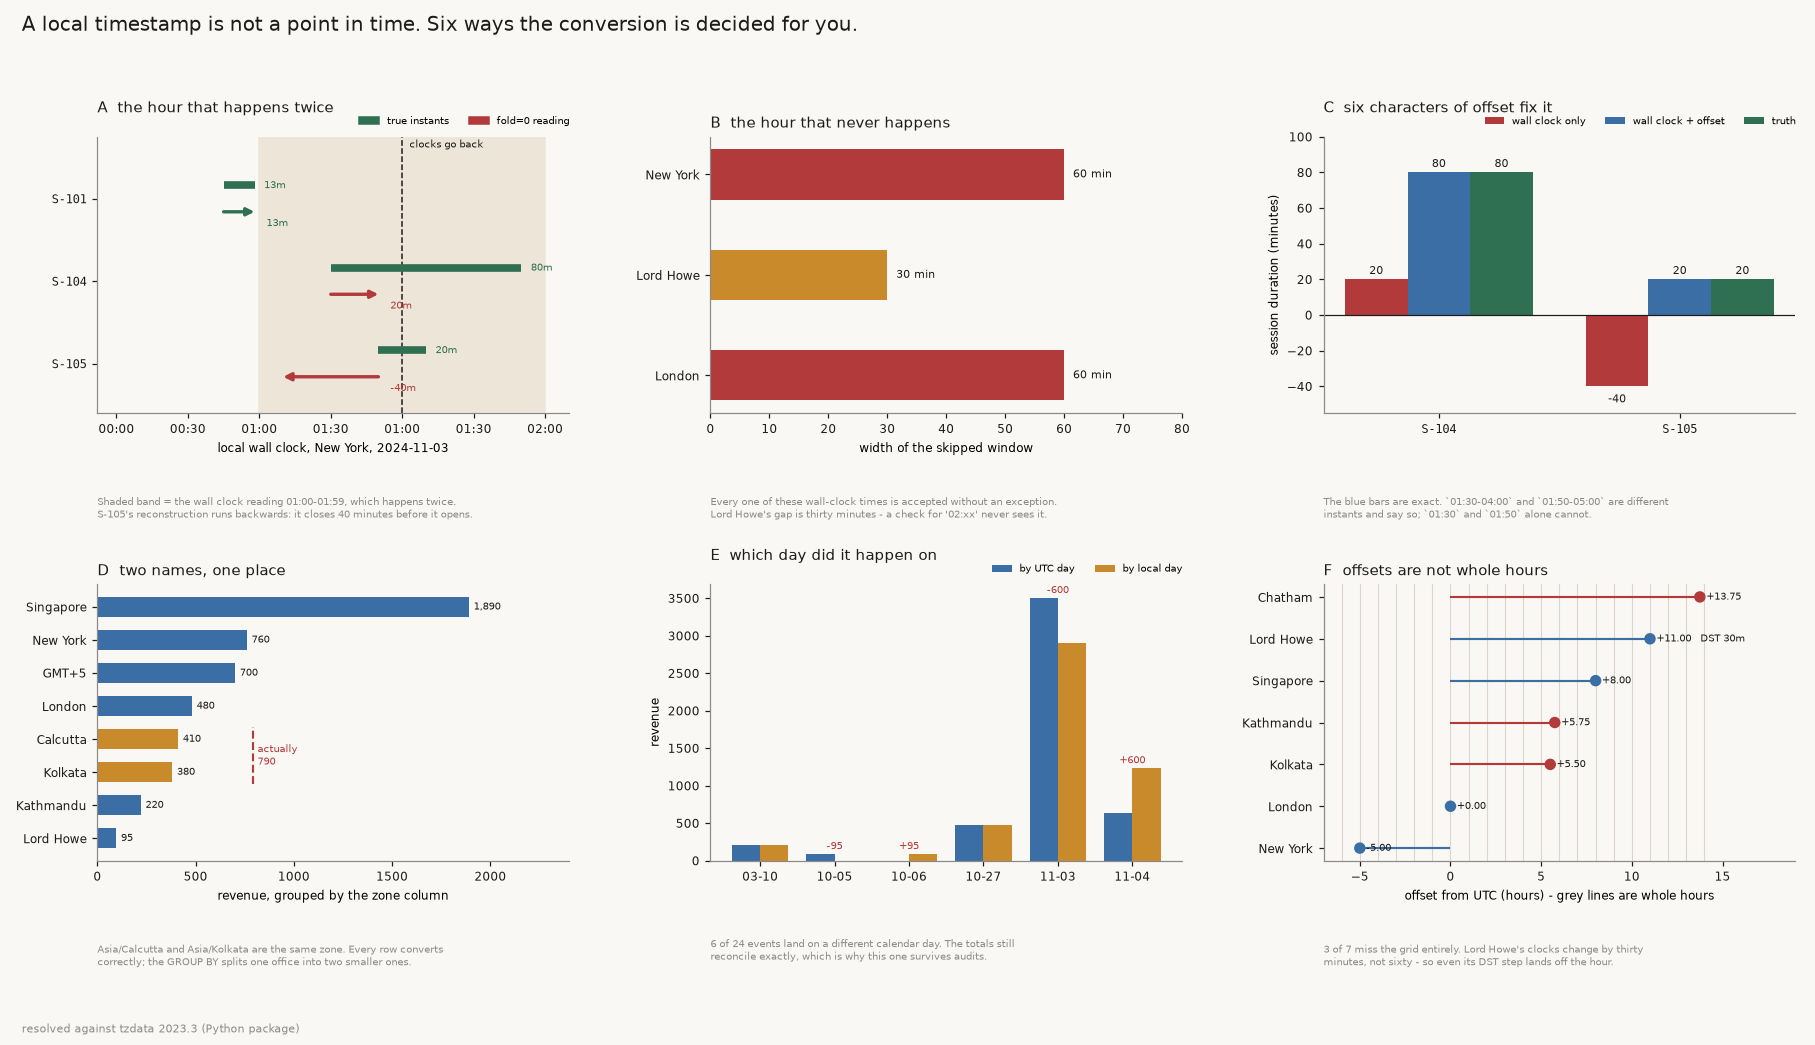

In [13]:
import os
from IPython.display import Image, display

if not os.path.exists("tz_audit_nb.png"):
    import urllib.request
    url = (
        "https://raw.githubusercontent.com/phoebefu6/phoebe-the-builder/main/"
        "data-engineering-pro/timezone-normalizer/tz_audit_nb.png"
    )
    try:
        urllib.request.urlretrieve(url, "tz_audit_nb.png")
    except Exception as exc:
        print("could not fetch the figure:", exc)

if os.path.exists("tz_audit_nb.png"):
    display(Image("tz_audit_nb.png"))
else:
    print("Run `python3 make_chart.py` in the repo to regenerate it.")

## Try your own column

The policies default to `raise` on a single value and `flag` on a column, because in
both hard cases the input does not determine the answer and a default that quietly
picks one is how a duration ends up negative in a table nobody re-reads.

In [14]:
from tznorm import resolve, normalize, audit, local_day, utc_day

# my_rows = [
#     {"local_ts": "2024-11-03 01:30", "zone": "America/New_York"},
#     {"local_ts": "2024-03-10 02:30", "zone": "America/New_York"},
#     {"local_ts": "2024-11-04 00:25", "zone": "Asia/Kathmandu"},
# ]
#
# print(audit(my_rows).text())                       # verdict first
# for r in normalize(my_rows):                       # flags rather than guesses
#     print(r.status, r.raw, r.utc, r.note)
#
# # when you genuinely have to pick, say so out loud:
# normalize(my_rows, ambiguous="earlier", nonexistent="shift_forward")

print("Uncomment and edit the block above.")

Uncomment and edit the block above.


---

**Streamlit version:**

```bash
pip install -r requirements.txt
streamlit run app.py
```

Reproduce every number here:

```bash
python3 test_tznorm.py   # 36 tests over the core
python3 evidence.py      # every table above
python3 make_chart.py    # the six-panel figure
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 139, Data Engineering Pro.
